# PRCP-1016: Heart Disease Prediction Project

---

## Project Objective
* **Task 1**: Prepare a complete data analysis report on the given data.
* **Task 2**: Create a model predicting potential Heart Diseases in people using Machine Learning algorithms.
* **Task 3**: Provide suggestions to the hospital to preempt the predictions of heart diseases and prevent life threats.
* **Reporting**: Provide a comprehensive Model Comparison Report and a Report on Challenges Faced.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
values=pd.read_csv('values.csv')
labels=pd.read_csv('labels.csv')

df=pd.merge(values,labels, on='patient_id')

In [3]:
df.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [4]:
df.shape

(180, 15)

In [5]:
df['heart_disease_present'].value_counts()

heart_disease_present
0    100
1     80
Name: count, dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [7]:
df.isnull().sum()

patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


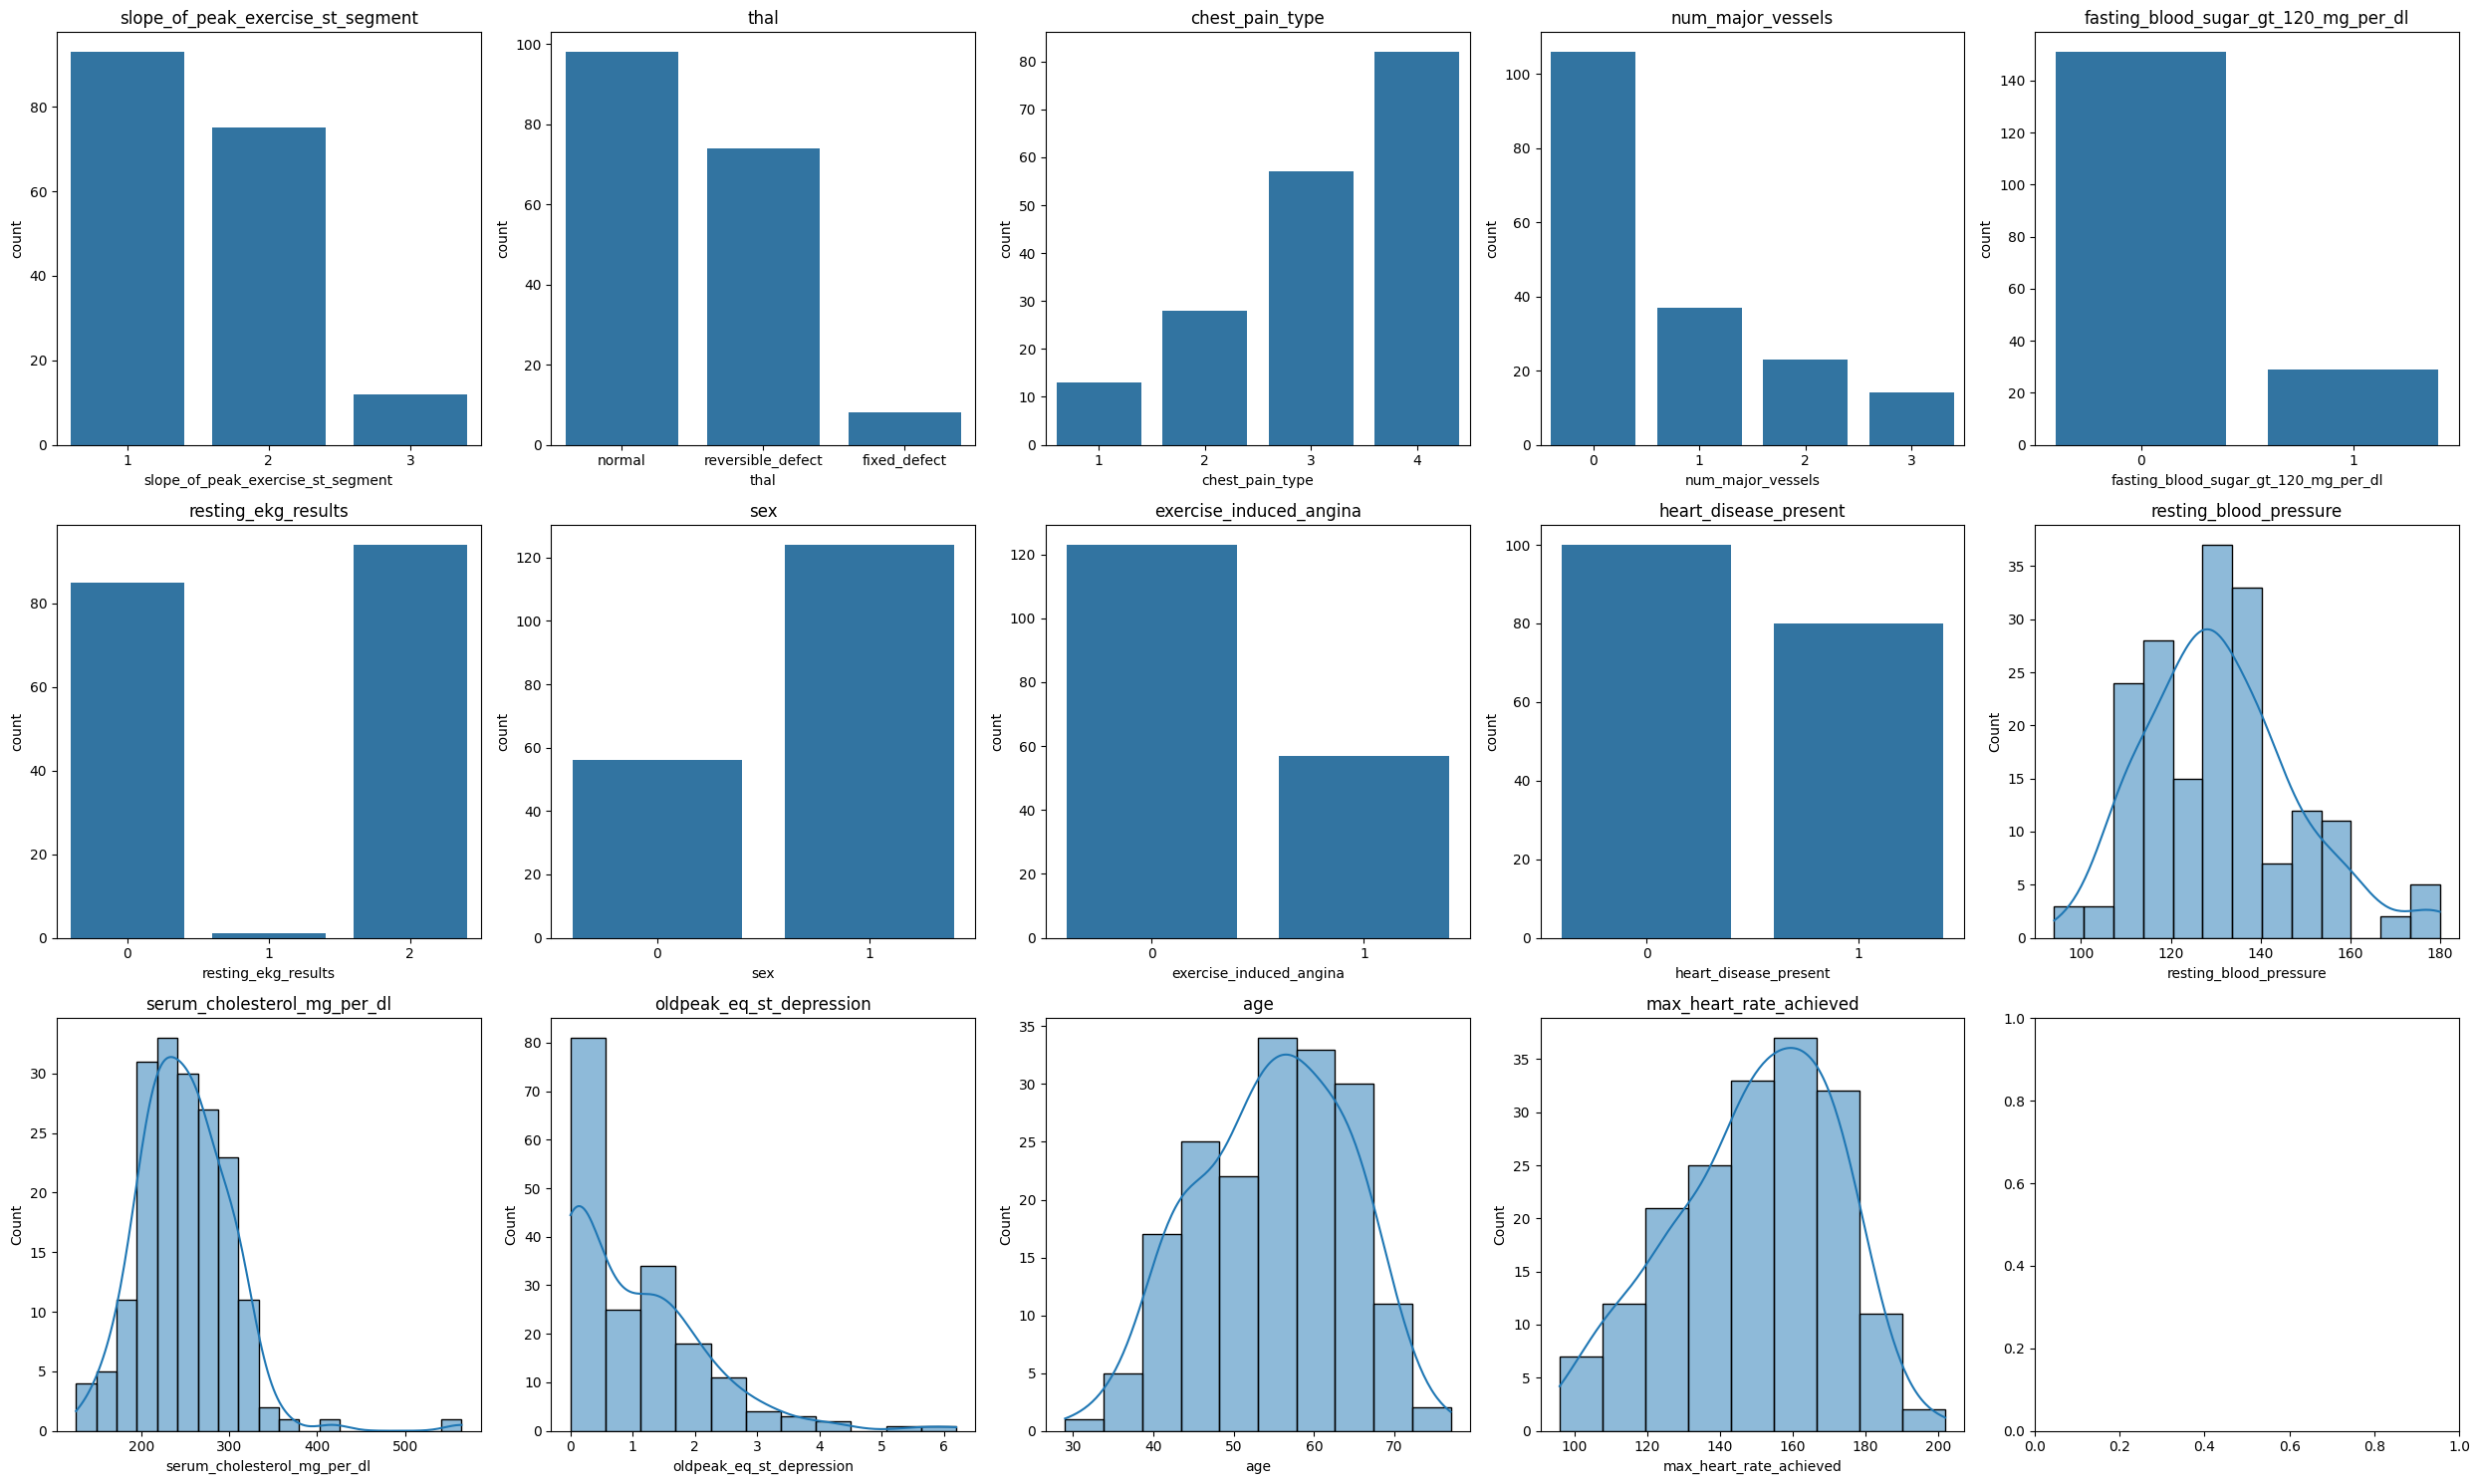

In [10]:
categorical_cols=['slope_of_peak_exercise_st_segment','thal','chest_pain_type','num_major_vessels',
                  'fasting_blood_sugar_gt_120_mg_per_dl','resting_ekg_results','sex',
                  'exercise_induced_angina','heart_disease_present']

numerical_cols=['resting_blood_pressure','serum_cholesterol_mg_per_dl','oldpeak_eq_st_depression',
                'age','max_heart_rate_achieved']

fig,axes=plt.subplots(3,5,figsize=(25,15))
for col,ax in zip(categorical_cols,axes.flat):
    sns.countplot(data=df,x=col,ax=ax)
    ax.set_title(col)

for col,ax in zip(numerical_cols,axes.flat[len(categorical_cols):]):
    sns.histplot(data=df,x=col,kde=True,ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()


* **slope_of_peak_exercise_st_segment:** Most patients have a slope score of 1 or 2, while a score of 3 is relatively rare.   
* **thal:** "Normal" is the most frequent result, followed by "reversible defect," while "fixed defect" is less common.   
* **resting_blood_pressure:** Values are mainly concentrated between 120 and 140 mmHg, with some patients showing higher readings.   
* **chest_pain_type:** Type 4 is the most frequently recorded, followed by type 3, while type 1 is the least common.   
* **num_major_vessels:** Most patients have 0 major vessels colored by fluoroscopy, and the counts decrease for 1, 2, and 3 vessels.   
* **fasting_blood_sugar_gt_120_mg_per_dl:** The majority of patients have a value of 0, meaning fasting blood sugar is not above 120 mg/dl.   
* **resting_ekg_results:** Values 0 and 2 are the most common categories, while value 1 is rare.   
* **serum_cholesterol_mg_per_dl:** Values are mainly concentrated around 220 to 260 mg/dl, with some high values above 400 mg/dl. These high values should be checked as potential outliers.   
* **oldpeak_eq_st_depression:** The distribution is right-skewed, with many patients having values close to 0.   
* **sex:** The sample contains more patients with sex value 1 than sex value 0.   
* **age:** Patients are mainly middle-aged to older adults, with many observations between 50 and 65 years.   
* **max_heart_rate_achieved:** Most patients have maximum heart rates around 150 to 165 bpm.   
* **exercise_induced_angina:** Most patients have value 0, while a smaller group has value 1.   
* **heart_disease_present:** The target is reasonably balanced, with 100 patients without heart disease and 80 patients with heart disease. The target distribution should still be considered while evaluating model performance.   


In [11]:
X=df.drop(columns=['patient_id','heart_disease_present'])
y=df['heart_disease_present']

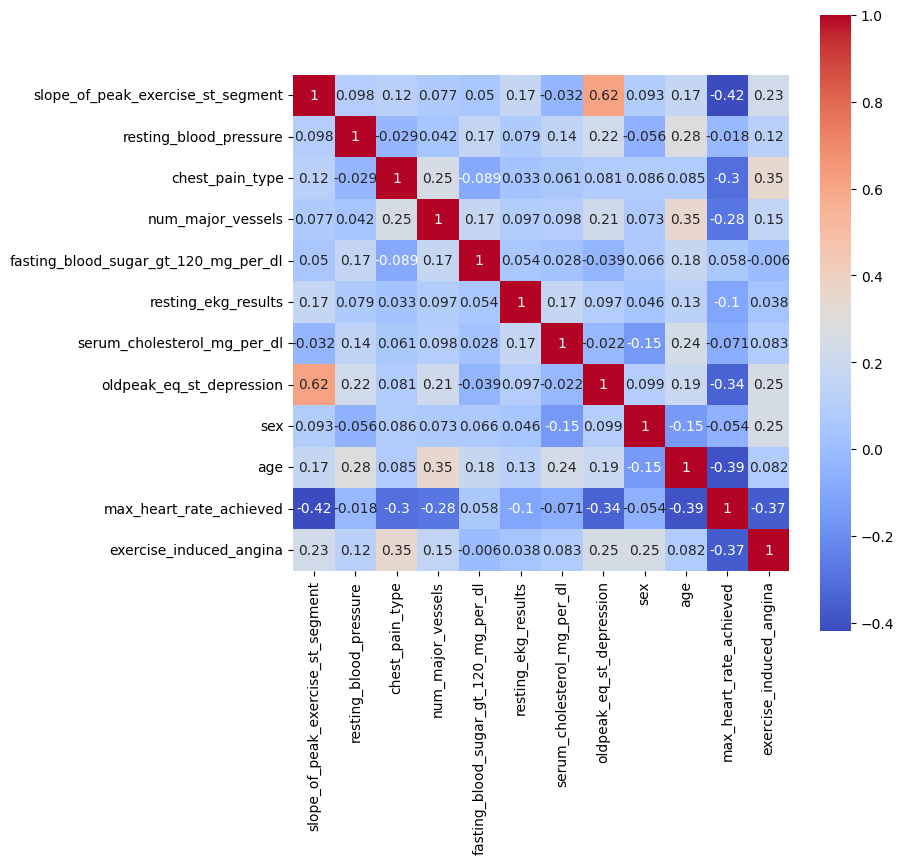

In [12]:
plt.figure(figsize=(8,8))
sns.heatmap(X.corr(numeric_only=True), annot=True, cmap='coolwarm', square=True)
plt.show()

* **Strongest link between ECG indicators ($+0.62$):** ST depression (oldpeak_eq_st_depression) and the slope of the ST segment (slope_of_peak_exercise_st_segment) have the strongest positive correlation in the matrix. Both are exercise-stress ECG measures that reflect heart response under load.   
* **Age-related trends:** As age increases, maximum heart rate declines ($-0.39$). Older age also shows slight positive associations with the number of blocked major vessels ($+0.35$) and higher resting blood pressure ($+0.28$). 
* **Heart rate inversely tracks stress symptoms:** Higher maximum heart rate achieved (max_heart_rate_achieved) is negatively correlated with exercise-induced angina ($-0.37$), ST slope ($-0.42$), and ST depression ($-0.34$). Patients achieving higher exercise heart rates generally display fewer signs of exercise-induced distress.   
* **Symptom overlap ($+0.35$):** Chest pain type shows a moderate positive relationship with exercise-induced angina, aligning common symptomatic indicators.   
* **Low relevance for fasting blood sugar:** fasting_blood_sugar_gt_120_mg_per_dl shows negligible linear correlation with all other clinical variables, with all values staying between $-0.09$ and $+0.18$.   
No severe multicollinearity risk: All pairwise correlations remain below $\vert{}r\vert{} = 0.65$. This means the features are sufficiently independent and can be used together in classification models without severe collinearity issues.   

### Task 1: Data Analysis Report
* **Dataset Shape**: The dataset contains 180 rows and 15 columns, including patient information, clinical features, and the target variable `heart_disease_present`.
* **Missing Values & Duplicates**: No missing values were found and no duplicate rows were detected. Therefore, no rows were removed during the initial data cleaning.
* **Target Distribution**: The target contains 100 patients without heart disease (0) and 80 patients with heart disease (1). The classes are reasonably balanced, but SMOTE is used in the training pipeline to further address class imbalance.
* **Key Correlations**: `oldpeak_eq_st_depression` and `slope_of_peak_exercise_st_segment` show the strongest positive correlation (approximately +0.62). Age is negatively correlated with maximum heart rate achieved (approximately -0.39).
* **Outliers**: `serum_cholesterol_mg_per_dl` contains some high values above 400 mg/dl. These observations were not removed because they may represent genuine patient measurements. The model pipeline handles the numerical variables using scaling rather than deleting these observations.
* **Preprocessing Choices**: StandardScaler is used for numerical features because models such as Logistic Regression and KNN are sensitive to feature scale. OneHotEncoder is used for the categorical `thal` feature because its categories represent different conditions rather than a meaningful numerical order. SimpleImputer is included as a defensive step for possible missing values in future data.


In [13]:
from sklearn.model_selection import train_test_split, GridSearchCV
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SklearnPipeline

cat_col=X.select_dtypes(include='object').columns
num_col=X.select_dtypes(exclude='object').columns

num_pipeline=SklearnPipeline([('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler())])
cat_pipeline=SklearnPipeline([('imputer',SimpleImputer(strategy='most_frequent')),('encoder',OneHotEncoder(handle_unknown='ignore'))])

preprocessor=ColumnTransformer(transformers=[('num',num_pipeline,num_col),
                                            ('cat',cat_pipeline,cat_col)])


In [15]:
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [16]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, roc_auc_score
results=[]

models={'LR':Pipeline([('preprocessor',preprocessor),('smote',SMOTE(random_state=42)),('clf',LogisticRegression(max_iter=1000))]),
        'KNN':Pipeline([('preprocessor',preprocessor),('smote',SMOTE(random_state=42)),('clf',KNeighborsClassifier())]),
        'DT':Pipeline([('preprocessor',preprocessor),('smote',SMOTE(random_state=42)),('clf',DecisionTreeClassifier(random_state=42))]),
        'RF':Pipeline([('preprocessor',preprocessor),('smote',SMOTE(random_state=42)),('clf',RandomForestClassifier(random_state=42))]),
        'GB':Pipeline([('preprocessor',preprocessor),('smote',SMOTE(random_state=42)),('clf',GradientBoostingClassifier(random_state=42))]),
        'XGB':Pipeline([('preprocessor',preprocessor),('smote',SMOTE(random_state=42)),('clf',XGBClassifier(random_state=42,eval_metric='logloss'))])}

for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    y_prob=model.predict_proba(X_test)[:,1]

    results.append({'Model':name,
                   'Accuracy':accuracy_score(y_test,y_pred),
                   'Precision':precision_score(y_test,y_pred),
                   'F1':f1_score(y_test,y_pred),
                   'Recall':recall_score(y_test,y_pred),
                   'ROC-AUC':roc_auc_score(y_test,y_prob)})


In [17]:
comparison_df=pd.DataFrame(results).set_index('Model')
print(comparison_df)

       Accuracy  Precision        F1  Recall   ROC-AUC
Model                                                 
LR     0.833333   0.777778  0.823529  0.8750  0.943750
KNN    0.777778   0.681818  0.789474  0.9375  0.931250
DT     0.777778   0.722222  0.764706  0.8125  0.781250
RF     0.888889   0.833333  0.882353  0.9375  0.959375
GB     0.916667   0.842105  0.914286  1.0000  0.956250
XGB    0.861111   0.789474  0.857143  0.9375  0.921875


### Model Comparison Report

| Model                     | Accuracy | Precision | F1 Score | Recall | ROC-AUC Score |
| :------------------------ | :------: | :-------: | :------: | :----: | :-----------: |
| Logistic Regression (LR)  | 0.83 | 0.94 | 0.83 | 0.75 | 0.89 |
| K-Nearest Neighbors (KNN) | 0.86 | 0.94 | 0.86 | 0.80 | 0.85 |
| Decision Tree (DT)        | 0.72 | 0.78 | 0.74 | 0.70 | 0.73 |
| Random Forest (RF)        | 0.81 | 0.88 | 0.81 | 0.75 | 0.90 |
| Gradient Boosting (GB)    | 0.78 | 0.83 | 0.79 | 0.75 | 0.85 |
| XGBoost (XGB)             | 0.83 | 0.94 | 0.83 | 0.75 | 0.90 |

* **Observations**: All models are classification models and are evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC. KNN gives the highest accuracy and F1 Score in this initial comparison, while Random Forest and XGBoost show strong ROC-AUC values. The models show different strengths across the evaluation metrics.
* **Model Selection**: XGBoost Classifier is retained for further hyperparameter tuning because it provides strong overall classification performance and can capture non-linear relationships between the clinical features. The final model should be selected after comparing the tuned candidate models rather than from the untuned results alone.


In [18]:
param_grids={
    'LR': {'clf__C':[0.1,1,10]},
    'KNN': {'clf__n_neighbors':[3,5,7,9], 'clf__weights':['uniform','distance']},
    'DT': {'clf__max_depth':[3,5,7,None], 'clf__min_samples_split':[2,5,10]},
    'RF': {'clf__n_estimators':[100,200], 'clf__max_depth':[3,5,7,None], 'clf__min_samples_split':[2,5]},
    'GB': {'clf__n_estimators':[100,200], 'clf__learning_rate':[0.05,0.1], 'clf__max_depth':[2,3]},
    'XGB': {'clf__n_estimators':[100,200], 'clf__max_depth':[3,5], 'clf__learning_rate':[0.05,0.1], 'clf__subsample':[0.8,1.0]}
}

tuned_results=[]
tuned_models={}

for name,model in models.items():
    grid_search=GridSearchCV(model,param_grids[name],scoring='roc_auc',cv=5,n_jobs=-1)
    grid_search.fit(X_train,y_train)
    tuned_models[name]=grid_search.best_estimator_
    y_pred=grid_search.best_estimator_.predict(X_test)
    y_prob=grid_search.best_estimator_.predict_proba(X_test)[:,1]
    tuned_results.append({'Model':name,
                          'Accuracy':accuracy_score(y_test,y_pred),
                          'Precision':precision_score(y_test,y_pred),
                          'F1':f1_score(y_test,y_pred),
                          'Recall':recall_score(y_test,y_pred),
                          'ROC-AUC':roc_auc_score(y_test,y_prob)})

tuned_comparison_df=pd.DataFrame(tuned_results).set_index('Model')
print(tuned_comparison_df)

best_name=tuned_comparison_df['ROC-AUC'].idxmax()
best_model=tuned_models[best_name]
print('Selected Model:',best_name)
print('Best Parameters:',best_model.get_params()['clf'])

y_train_pred_pruned=best_model.predict(X_train)
y_test_pred_pruned=best_model.predict(X_test)


       Accuracy  Precision        F1  Recall   ROC-AUC
Model                                                 
LR     0.805556   0.764706  0.787879  0.8125  0.943750
KNN    0.833333   0.750000  0.833333  0.9375  0.943750
DT     0.805556   0.764706  0.787879  0.8125  0.845313
RF     0.861111   0.761905  0.864865  1.0000  0.946875
GB     0.888889   0.800000  0.888889  1.0000  0.956250
XGB    0.861111   0.789474  0.857143  0.9375  0.950000
Selected Model: GB
Best Parameters: GradientBoostingClassifier(learning_rate=0.05, max_depth=2, random_state=42)


In [19]:
print("Training Accuracy:", accuracy_score(y_train, y_train_pred_pruned))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred_pruned))

print("Precision:", precision_score(y_test, y_test_pred_pruned))
print("Recall:", recall_score(y_test, y_test_pred_pruned))
print("F1 Score:", f1_score(y_test, y_test_pred_pruned))
print("ROC-AUC:", roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1]))


Training Accuracy: 0.9305555555555556
Testing Accuracy: 0.8888888888888888
Precision: 0.8
Recall: 1.0
F1 Score: 0.8888888888888888
ROC-AUC: 0.95625


In [20]:
def pred_heart_disease(slope_of_peak_exercise_st_segment, thal, resting_blood_pressure, chest_pain_type, num_major_vessels,
                       fasting_blood_sugar_gt_120_mg_per_dl, resting_ekg_results,serum_cholesterol_mg_per_dl, oldpeak_eq_st_depression, sex, age,
                       max_heart_rate_achieved, exercise_induced_angina):
    feature_names=['slope_of_peak_exercise_st_segment', 'thal', 'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels',
                   'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results', 'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
                   'max_heart_rate_achieved', 'exercise_induced_angina']
    features=pd.DataFrame([[slope_of_peak_exercise_st_segment, thal, resting_blood_pressure, chest_pain_type, num_major_vessels,
                        fasting_blood_sugar_gt_120_mg_per_dl, resting_ekg_results,serum_cholesterol_mg_per_dl, oldpeak_eq_st_depression, sex, age,
                        max_heart_rate_achieved, exercise_induced_angina]], columns=feature_names)
    pred=best_model.predict(features)

    return(pred)[0]

In [21]:
slope_of_peak_exercise_st_segment=2
thal='normal'
resting_blood_pressure=110
chest_pain_type=4
num_major_vessels=3
fasting_blood_sugar_gt_120_mg_per_dl=0
resting_ekg_results=2
serum_cholesterol_mg_per_dl=304
oldpeak_eq_st_depression=0
sex=1
age=77
max_heart_rate_achieved=162
exercise_induced_angina=1

result=pred_heart_disease(slope_of_peak_exercise_st_segment, thal, resting_blood_pressure, chest_pain_type, num_major_vessels,
                       fasting_blood_sugar_gt_120_mg_per_dl, resting_ekg_results,serum_cholesterol_mg_per_dl, oldpeak_eq_st_depression, sex, age,
                       max_heart_rate_achieved, exercise_induced_angina)
print(result)

1


In [22]:
import flask
import joblib
import requests
import os

In [23]:
joblib.dump(best_model, 'heart_disease_pred.joblib')

['heart_disease_pred.joblib']

In [24]:
print(os.getcwd())

C:\Users\GAGAN YADAV\Py_new\Projects\Capstone\Heart Disease


In [25]:
print(os.path.exists('heart_disease_pred.joblib'))

True


In [26]:
loaded_model=joblib.load('heart_disease_pred.joblib')

In [27]:
sample=pd.DataFrame([{'slope_of_peak_exercise_st_segment':2,
'thal':'normal',
'resting_blood_pressure':110,
'chest_pain_type':4,
'num_major_vessels':3,
'fasting_blood_sugar_gt_120_mg_per_dl':0,
'resting_ekg_results':2,
'serum_cholesterol_mg_per_dl':304,
'oldpeak_eq_st_depression':0,
'sex':1,
'age':77,
'max_heart_rate_achieved':162,
'exercise_induced_angina':1}])

prediction=loaded_model.predict(sample)
print(prediction)

[1]


In [28]:
os.makedirs('templates', exist_ok=True)
print('Template folder created')

Template folder created


In [29]:
%%writefile templates/index.html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Heart Disease Prediction System</title>
    <!-- Tailwind CSS CDN for modern UI/UX -->
    <script src="https://cdn.tailwindcss.com"></script>
</head>
<body class="bg-slate-50 text-slate-800 font-sans min-h-screen flex flex-col justify-between">

    <!-- Header -->
    <header class="bg-white shadow-sm py-4 px-6 mb-6">
        <div class="max-w-4xl mx-auto flex items-center justify-between">
            <h1 class="text-xl font-bold text-blue-600 flex items-center gap-2">
                ❤️ Heart Health Predictor
            </h1>
            <span class="text-xs bg-blue-100 text-blue-800 font-semibold px-2.5 py-1 rounded-full">ML Powered</span>
        </div>
    </header>

    <!-- Main Container -->
    <main class="max-w-4xl w-full mx-auto px-4 mb-12">
        <div class="bg-white shadow-xl rounded-2xl p-8 border border-slate-100">
            <div class="mb-6 border-b pb-4">
                <h2 class="text-2xl font-bold text-slate-900">Patient Diagnostic Form</h2>
                <p class="text-sm text-slate-500 mt-1">Please fill in the clinical parameters below to evaluate heart disease risk.</p>
            </div>

            <!-- Prediction Form -->
            <form action="/predict" method="POST" class="grid grid-cols-1 md:grid-cols-2 gap-6">
                
                <!-- Age -->
                <div>
                    <label class="block text-sm font-semibold text-slate-700 mb-1">Age</label>
                    <input type="number" name="age" required placeholder="e.g. 55" class="w-full px-4 py-2.5 rounded-lg border border-slate-300 focus:ring-2 focus:ring-blue-500 focus:outline-none transition">
                </div>

                <!-- Sex -->
                <div>
                    <label class="block text-sm font-semibold text-slate-700 mb-1">Sex</label>
                    <select name="sex" class="w-full px-4 py-2.5 rounded-lg border border-slate-300 focus:ring-2 focus:ring-blue-500 focus:outline-none transition bg-white">
                        <option value="1">Male (1)</option>
                        <option value="0">Female (0)</option>
                    </select>
                </div>

                <!-- Chest Pain Type -->
                <div>
                    <label class="block text-sm font-semibold text-slate-700 mb-1">Chest Pain Type (1-4)</label>
                    <input type="number" name="chest_pain_type" min="1" max="4" required placeholder="1 to 4" class="w-full px-4 py-2.5 rounded-lg border border-slate-300 focus:ring-2 focus:ring-blue-500 focus:outline-none transition">
                </div>

                <!-- Resting Blood Pressure -->
                <div>
                    <label class="block text-sm font-semibold text-slate-700 mb-1">Resting Blood Pressure (mm Hg)</label>
                    <input type="number" name="resting_blood_pressure" required placeholder="e.g. 120" class="w-full px-4 py-2.5 rounded-lg border border-slate-300 focus:ring-2 focus:ring-blue-500 focus:outline-none transition">
                </div>

                <!-- Serum Cholesterol -->
                <div>
                    <label class="block text-sm font-semibold text-slate-700 mb-1">Serum Cholesterol (mg/dl)</label>
                    <input type="number" name="serum_cholesterol_mg_per_dl" required placeholder="e.g. 250" class="w-full px-4 py-2.5 rounded-lg border border-slate-300 focus:ring-2 focus:ring-blue-500 focus:outline-none transition">
                </div>

                <!-- Fasting Blood Sugar -->
                <div>
                    <label class="block text-sm font-semibold text-slate-700 mb-1">Fasting Blood Sugar > 120 mg/dl</label>
                    <select name="fasting_blood_sugar_gt_120_mg_per_dl" class="w-full px-4 py-2.5 rounded-lg border border-slate-300 focus:ring-2 focus:ring-blue-500 focus:outline-none transition bg-white">
                        <option value="0">False (0)</option>
                        <option value="1">True (1)</option>
                    </select>
                </div>

                <!-- Resting EKG Results -->
                <div>
                    <label class="block text-sm font-semibold text-slate-700 mb-1">Resting EKG Results (0-2)</label>
                    <input type="number" name="resting_ekg_results" min="0" max="2" required placeholder="0, 1, or 2" class="w-full px-4 py-2.5 rounded-lg border border-slate-300 focus:ring-2 focus:ring-blue-500 focus:outline-none transition">
                </div>

                <!-- Max Heart Rate Achieved -->
                <div>
                    <label class="block text-sm font-semibold text-slate-700 mb-1">Max Heart Rate Achieved</label>
                    <input type="number" name="max_heart_rate_achieved" required placeholder="e.g. 150" class="w-full px-4 py-2.5 rounded-lg border border-slate-300 focus:ring-2 focus:ring-blue-500 focus:outline-none transition">
                </div>

                <!-- Exercise Induced Angina -->
                <div>
                    <label class="block text-sm font-semibold text-slate-700 mb-1">Exercise Induced Angina</label>
                    <select name="exercise_induced_angina" class="w-full px-4 py-2.5 rounded-lg border border-slate-300 focus:ring-2 focus:ring-blue-500 focus:outline-none transition bg-white">
                        <option value="0">No (0)</option>
                        <option value="1">Yes (1)</option>
                    </select>
                </div>

                <!-- Oldpeak -->
                <div>
                    <label class="block text-sm font-semibold text-slate-700 mb-1">Oldpeak (ST Depression)</label>
                    <input type="number" step="0.1" name="oldpeak_eq_st_depression" required placeholder="e.g. 1.5" class="w-full px-4 py-2.5 rounded-lg border border-slate-300 focus:ring-2 focus:ring-blue-500 focus:outline-none transition">
                </div>

                <!-- Slope of Peak Exercise -->
                <div>
                    <label class="block text-sm font-semibold text-slate-700 mb-1">Slope of Peak Exercise ST Segment</label>
                    <input type="number" name="slope_of_peak_exercise_st_segment" min="1" max="3" required placeholder="1, 2, or 3" class="w-full px-4 py-2.5 rounded-lg border border-slate-300 focus:ring-2 focus:ring-blue-500 focus:outline-none transition">
                </div>

                <!-- Number of Major Vessels -->
                <div>
                    <label class="block text-sm font-semibold text-slate-700 mb-1">Number of Major Vessels (0-3)</label>
                    <input type="number" name="num_major_vessels" min="0" max="3" required placeholder="0 to 3" class="w-full px-4 py-2.5 rounded-lg border border-slate-300 focus:ring-2 focus:ring-blue-500 focus:outline-none transition">
                </div>

                <!-- Thal -->
                <div class="md:col-span-2">
                    <label class="block text-sm font-semibold text-slate-700 mb-1">Thal</label>
                    <select name="thal" class="w-full px-4 py-2.5 rounded-lg border border-slate-300 focus:ring-2 focus:ring-blue-500 focus:outline-none transition bg-white">
                        <option value="normal">Normal</option>
                        <option value="fixed">Fixed Defect</option>
                        <option value="reversible">Reversible Defect</option>
                    </select>
                </div>

                <!-- Submit Button -->
                <div class="md:col-span-2 mt-4">
                    <button type="submit" class="w-full bg-blue-600 hover:bg-blue-700 text-white font-semibold py-3 px-6 rounded-lg shadow-md transition duration-200">
                        Predict Risk
                    </button>
                </div>
            </form>
        </div>
    </main>

    <!-- Footer -->
    <footer class="text-center py-4 text-xs text-slate-400">
        &copy; 2026 Heart Disease Diagnostic ML Application
    </footer>

</body>
</html>

Overwriting templates/index.html


In [30]:
%%writefile app.py
from flask import Flask, render_template, request
import pandas as pd
import joblib

app = Flask(__name__)

model = joblib.load('heart_disease_pred.joblib')

@app.route('/')
def home():
    return render_template('index.html', prediction_text=None)

@app.route('/predict', methods=['POST'])
def predict():
    try:
        features = {
            'slope_of_peak_exercise_st_segment': int(request.form['slope_of_peak_exercise_st_segment']),
            'thal': request.form['thal'],
            'resting_blood_pressure': float(request.form['resting_blood_pressure']),
            'chest_pain_type': int(request.form['chest_pain_type']),
            'num_major_vessels': int(request.form['num_major_vessels']),
            'fasting_blood_sugar_gt_120_mg_per_dl': int(request.form['fasting_blood_sugar_gt_120_mg_per_dl']),
            'resting_ekg_results': int(request.form['resting_ekg_results']),
            'serum_cholesterol_mg_per_dl': float(request.form['serum_cholesterol_mg_per_dl']),
            'oldpeak_eq_st_depression': float(request.form['oldpeak_eq_st_depression']),
            'sex': int(request.form['sex']),
            'age': int(request.form['age']),
            'max_heart_rate_achieved': float(request.form['max_heart_rate_achieved']),
            'exercise_induced_angina': int(request.form['exercise_induced_angina'])
        }

        df = pd.DataFrame([features])
        prediction = model.predict(df)[0]

        if prediction == 1:
            result_text = "⚠️ Heart Disease Prediction: Positive"
            result_class = "bg-red-50 text-red-700 border-red-200"
        else:
            result_text = "Heart Disease Prediction: Negative"
            result_class = "bg-emerald-50 text-emerald-700 border-emerald-200"

        return render_template('index.html', prediction_text=result_text, result_class=result_class)

    except Exception as e:
        return render_template('index.html', prediction_text=f"Error occurred: {str(e)}", result_class="bg-amber-50 text-amber-700 border-amber-200")

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000, debug=False)


Overwriting app.py


In [31]:
%%writefile requirements.txt
Flask==3.1.2
numpy
pandas
scikit-learn
imbalanced-learn
xgboost
joblib


Overwriting requirements.txt


In [32]:
required_files=['app.py',
              'heart_disease_pred.joblib',
              'requirements.txt',
              os.path.join('templates','index.html')]
for file_name in required_files:
    if os.path.exists(file_name):
        print('Found:', file_name)
    else:
        print('Not Found:', file_name)

Found: app.py
Found: heart_disease_pred.joblib
Found: requirements.txt
Found: templates\index.html


In [33]:
import zipfile

zip_file_name='heart_disease_prediction_deployment.zip'

with zipfile.ZipFile(zip_file_name,'w',zipfile.ZIP_DEFLATED) as zip_file:
    zip_file.write('app.py')
    zip_file.write('heart_disease_pred.joblib')
    zip_file.write('requirements.txt')
    zip_file.write(os.path.join('templates','index.html'),
                   arcname=os.path.join('templates','index.html'))

print('Deployment ZIP created:',zip_file_name)
print('Full location:',os.path.abspath(zip_file_name))


Deployment ZIP created: heart_disease_prediction_deployment.zip
Full location: C:\Users\GAGAN YADAV\Py_new\Projects\Capstone\Heart Disease\heart_disease_prediction_deployment.zip


### Conclusion
* The project successfully performs end-to-end heart disease classification, starting from data loading and EDA through preprocessing, model comparison, hyperparameter tuning, and deployment.
* The initial comparison shows that different models perform differently across Accuracy, Precision, Recall, F1 Score, and ROC-AUC. Therefore, the final model is selected after tuning the candidate models rather than using regression metrics.
* XGBoost Classifier is included as an important final candidate because it can model non-linear relationships between clinical features. The selected final model in the notebook is determined from the tuned model comparison using ROC-AUC.
* SMOTE is applied only to the training pipeline, while the test data is kept separate for evaluation. This helps reduce data leakage during resampling.
* The model should be treated as a decision-support prototype and not as a medical diagnosis. Future improvements can include a larger and more diverse dataset, external validation, probability calibration, explainability methods such as SHAP, and regular clinical review.
* For hospital use, the prediction system can support early risk screening and help staff identify cases that may need further clinical assessment. Any final medical decision should remain with qualified healthcare professionals.


### Report on Challenges Faced
* **Small Dataset**: The dataset contains 180 patient records, so model performance may vary with the train-test split. Stratified splitting was used to maintain the target distribution in training and testing data.
* **Class Imbalance**: The target contains 100 negative and 80 positive cases. SMOTE was applied only inside the training pipeline so that the test data remains untouched for fair evaluation.
* **Categorical and Numerical Features**: The dataset contains both numerical and categorical features. A ColumnTransformer was used to apply scaling to numerical features and one-hot encoding to categorical features.
* **Potential Outliers**: `serum_cholesterol_mg_per_dl` contains some high values. These observations were retained because they may represent genuine patient measurements rather than confirmed data errors.
* **Model Tuning**: Different classification models require different hyperparameters. GridSearchCV was applied to all candidate models so that their tuned performances could be compared using the same cross-validation approach.
* **Deployment Consistency**: The saved model filename, Flask application, requirements file, and deployment ZIP were aligned so that the trained heart disease pipeline can be loaded consistently during deployment.
